<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/workshop_glioma/main/Figuras/banner.png"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# **Workshop: Decodificación de Gliomas con ML e IA Interpretable**
# **Proyecto Endowment I+D: DI-07-25/ICS | UNAB - PUC - FALP**
---

# **Formulación Física: Del Espacio Real al Espacio K**

 En Resonancia Magnética (MRI), la señal que detectan las bobinas del equipo no es una imagen directa, sino una señal en el dominio de la frecuencia, conocida como Espacio K.

**1. La Transformada de Fourier 2D**

 La relación matemática que nos permite viajar entre la imagen $I(x, y)$ y su representación en frecuencias $S(k_x, k_y)$ es la Transformada de Fourier:$$S(k_x, k_y) = \iint I(x, y) e^{-i 2\pi (k_x x + k_y y)} dx dy$$Donde:$k_x, k_y$: Son las frecuencias espaciales (coordenadas del Espacio K).$I(x, y)$: Es la intensidad de los protones en la posición $(x, y)$.

 **2. Reconstrucción de la Imagen**

 Para obtener la imagen clínica que el radiólogo analiza, aplicamos la Transformada Inversa de Fourier (IFFT):$$I(x, y) = \iint S(k_x, k_y) e^{i 2\pi (k_x x + k_y y)} dk_x dk_y$$


**3. Anatomía del Espacio K**

 Físicamente, la distribución de los datos en este espacio sigue una regla fundamental:

 * **Centro del Espacio K (Bajas Frecuencias):** Contiene la información del contraste y las formas generales (la "energía" de la imagen). Si se pierde, la imagen pierde su estructura básica.

 * **Periferia del Espacio K (Altas Frecuencias):** Contiene la información de los bordes, detalles finos y resolución. Si se pierde, la imagen se ve borrosa (desenfocada).


 **Nota:** En la práctica, el tiempo de adquisición de una RM depende de cuántas líneas del Espacio K logramos llenar. Entender esto es clave para técnicas de aceleración como el Parallel Imaging o Compressed Sensing.

# **1. Preparación y Carga de Datos**
Primero, necesitamos descargar el archivo y cargar la librería scipy.io para leer el formato .mat.

In [4]:
import numpy as np
import scipy.io
import requests

# 1. Descargar el archivo
url = 'https://github.com/pamelaFranco/workshop_glioma/raw/main/Dataset/T1w_SE.mat'
r = requests.get(url, allow_redirects=True)
with open('dicom_images.mat', 'wb') as f:
    f.write(r.content)

# 2. Cargar y detectar la llave correcta
data = scipy.io.loadmat('dicom_images.mat')

# Filtramos las llaves automáticas de MATLAB para encontrar la de los datos
keys = [k for k in data.keys() if not k.startswith('_')]
print(f"Llaves encontradas en el archivo: {keys}")

# Intentamos tomar la primera llave que contenga los datos
nombre_llave = keys[0]
volumen = data[nombre_llave]

# 3. Extraer un corte (ajustando según dimensiones)
# Si el volumen es 3D (H, W, slices), tomamos el del medio
if volumen.ndim == 3:
    corte = volumen[:, :, volumen.shape[2] // 2]
else:
    corte = volumen # Si ya es 2D

print(f"Usando la variable: '{nombre_llave}'")
print(f"Dimensiones del corte: {corte.shape}")

Llaves encontradas en el archivo: ['im_final']
Usando la variable: 'im_final'
Dimensiones del corte: (256, 256)


**2. Visualización del Espacio K (Transformada Directa e Inversa)**

En este ejercicio, vamos a "diseccionar" la señal de resonancia magnética. Imagina que el Espacio K es una receta de cocina: algunos ingredientes dan el volumen (contraste) y otros los condimentos (detalles).

**¿Qué estamos haciendo con el Slider?**

Estamos aplicando un **Filtro de Paso Bajo (Low-pass Filter)** circular. Al mover el control de radio, estamos decidiendo cuánta información permitimos que regrese del dominio de la frecuencia al dominio de la imagen:

* **Radio Pequeño (El Corazón del Espacio K):** Aquí se concentra la mayor parte de la energía de la señal. Verás que la imagen recupera su brillo y sus formas generales (el contraste entre materia gris, blanca y líquido cefalorraquídeo), pero se ve **desenfocada**.

   * **Conclusión:** El centro nos dice "qué" estamos viendo, pero no dónde termina exactamente cada estructura.

* **Radio Grande (Las Afueras del Espacio K):** Al incluir las frecuencias altas que están lejos del centro, la imagen comienza a "enfocarse". Aparecen los bordes nítidos, la textura del tumor y las líneas finas de los surcos cerebrales.

   * ***Conclusión:** La periferia nos da la resolución espacial y el detalle fino.


**Actividad:**

* Lleva el slider al mínimo (valor 1-5). ¿Puedes reconocer que es un cerebro?

* Observa cómo, a partir de cierto punto, aumentar el radio ya no cambia mucho la imagen. ¡Eso significa que ya capturaste toda la información relevante!

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from ipywidgets import interact, IntSlider

# --- 1. Preparación de datos (Corte de la imagen) ---
# (Asumiendo que ya corriste el primer bloque para tener la variable 'corte')
espacio_k = np.fft.fftshift(np.fft.fft2(corte))
rows, cols = corte.shape
crow, ccol = rows // 2 , cols // 2

# --- 2. Función de actualización interactiva ---
def visualizar_filtro_k(radio):
    # Crear máscara circular
    mask = np.zeros((rows, cols))
    y, x = np.ogrid[:rows, :cols]
    mask_area = (x - ccol)**2 + (y - crow)**2 <= radio**2
    mask[mask_area] = 1

    # Aplicar al espacio k y reconstruir
    f_shift_filtrado = espacio_k * mask
    imagen_reconstruida = np.abs(np.fft.ifft2(np.fft.ifftshift(f_shift_filtrado)))

    # Visualización
    fig, ax = plt.subplots(1, 2, figsize=(15, 7))

    # Mostrar el Espacio K con la máscara resaltada
    ax[0].imshow(np.log(1 + np.abs(f_shift_filtrado)), cmap='gray')
    ax[0].set_title(f"Espacio K Filtrado (Radio: {radio} px)")
    ax[0].axis('off')

    # Mostrar la Imagen resultante
    ax[1].imshow(imagen_reconstruida, cmap='gray')
    ax[1].set_title("Imagen Reconstruida (Bajas Frecuencias)")
    ax[1].axis('off')

    plt.show()

# --- 3. Crear el Slider interactivo ---
interact(visualizar_filtro_k,
         radio=IntSlider(min=1, max=rows//2, step=2, value=20, description='Tamaño K:'));

interactive(children=(IntSlider(value=20, description='Tamaño K:', max=128, min=1, step=2), Output()), _dom_cl…

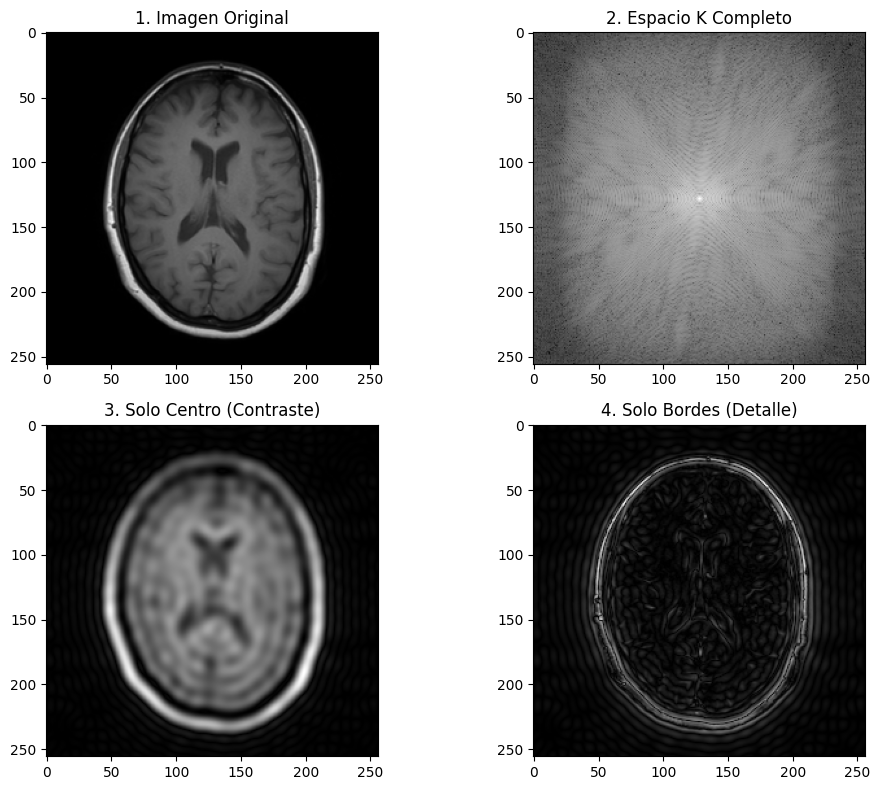

In [6]:
import matplotlib.pyplot as plt

# Transformada de Fourier
espacio_k = np.fft.fftshift(np.fft.fft2(corte))

# --- EXPERIMENTO: SOLO EL CENTRO (Bajas Frecuencias) ---
rows, cols = corte.shape
crow, ccol = rows // 2 , cols // 2
r = 20 # Radio del filtro
mask_low = np.zeros((rows, cols))
center_area = (np.ogrid[:rows, :cols][0] - crow)**2 + (np.ogrid[:rows, :cols][1] - ccol)**2 <= r**2
mask_low[center_area] = 1

f_shift_low = espacio_k * mask_low
img_low = np.abs(np.fft.ifft2(np.fft.ifftshift(f_shift_low)))

# --- EXPERIMENTO: SOLO LOS BORDES (Altas Frecuencias) ---
mask_high = 1 - mask_low # Invertimos la máscara
f_shift_high = espacio_k * mask_high
img_high = np.abs(np.fft.ifft2(np.fft.ifftshift(f_shift_high)))

# Visualización
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1); plt.imshow(corte, cmap='gray'); plt.title("1. Imagen Original")
plt.subplot(2, 3, 2); plt.imshow(np.log(1+np.abs(espacio_k)), cmap='gray'); plt.title("2. Espacio K Completo")

plt.subplot(2, 3, 4); plt.imshow(img_low, cmap='gray'); plt.title("3. Solo Centro (Contraste)")
plt.subplot(2, 3, 5); plt.imshow(img_high, cmap='gray'); plt.title("4. Solo Bordes (Detalle)")

plt.tight_layout()
plt.show()

# **⚠️ Nota Importante: Uso Educativo y Limitaciones Técnicas**

Este módulo tiene fines exclusivamente pedagógicos. La manipulación del Espacio K mostrada en este notebook es una simulación matemática post-procesamiento. En un entorno clínico real:

* **Diagnóstico:** Estos filtros alteran la morfología y el contraste de la imagen original. Nunca deben utilizarse para realizar diagnósticos médicos o evaluar la extensión de un glioma.

* **Adquisición:** En un resonador magnético, el Espacio K se llena físicamente mediante gradientes de campo magnético. Aquí estamos trabajando con una imagen ya reconstruida a la que le aplicamos una Transformada de Fourier artificial.

* **Complejidad:** El Espacio K real contiene datos complejos (parte real e imaginaria) que codifican fase y magnitud; en este ejercicio, simplificamos algunos pasos para facilitar la comprensión visual de las frecuencias espaciales.